# 1. Define a simple Deep Model

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
import matplotlib.pyplot as plt
import numpy as np


In [6]:
# Load dataset (MNIST for simplicity)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

Step 1: Define Deep Learning Model

In [7]:
def create_model(learning_rate):
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


Step 2: Train Model with Fixed Learning Rate

In [14]:
fixed_lr = 0.01
model_fixed = create_model(fixed_lr)

history_fixed = model_fixed.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8454 - loss: 0.4627 - val_accuracy: 0.9504 - val_loss: 0.1641
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9606 - loss: 0.1290 - val_accuracy: 0.9602 - val_loss: 0.1358
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9702 - loss: 0.1005 - val_accuracy: 0.9582 - val_loss: 0.1518
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9726 - loss: 0.0861 - val_accuracy: 0.9581 - val_loss: 0.1546
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9782 - loss: 0.0706 - val_accuracy: 0.9620 - val_loss: 0.1466
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9790 - loss: 0.0661 - val_accuracy: 0.9637 - val_loss: 0.1521
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9795 - loss: 0.0667 - val_accuracy: 0.9675 - val_loss: 0.1295
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9802 - loss: 0.0666 - val_accuracy: 0.

Step 3: Apply Learning Rate Decay

In [15]:
def lr_schedule(epoch, lr):
    return lr * 0.9


In [16]:
lr_scheduler = LearningRateScheduler(lr_schedule)

model_decay = create_model(0.01)

history_decay = model_decay.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    callbacks=[lr_scheduler],
    verbose=1
)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8688 - loss: 0.4306 - val_accuracy: 0.9578 - val_loss: 0.1436 - learning_rate: 0.0090
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9642 - loss: 0.1178 - val_accuracy: 0.9628 - val_loss: 0.1274 - learning_rate: 0.0081
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9749 - loss: 0.0800 - val_accuracy: 0.9658 - val_loss: 0.1240 - learning_rate: 0.0073
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9791 - loss: 0.0663 - val_accuracy: 0.9660 - val_loss: 0.1211 - learning_rate: 0.0066
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9850 - loss: 0.0476 - val_accuracy: 0.9734 - val_loss: 0.1056 - learning_rate: 0.0059
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9885 - loss: 0.0358 - val_accuracy: 0.9729 - val_loss: 0.1101 - learning_rate: 0.0053
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9903 - loss: 0.0271 - 

Step 4: Enable Early Stopping

In [17]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

model_early = create_model(0.01)

history_early = model_early.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8742 - loss: 0.4127 - val_accuracy: 0.9603 - val_loss: 0.1325
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9637 - loss: 0.1205 - val_accuracy: 0.9639 - val_loss: 0.1204
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9713 - loss: 0.0943 - val_accuracy: 0.9641 - val_loss: 0.1232
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9749 - loss: 0.0783 - val_accuracy: 0.9687 - val_loss: 0.1179
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9787 - loss: 0.0710 - val_accuracy: 0.9639 - val_loss: 0.1361
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9787 - loss: 0.0694 - val_accuracy: 0.9649 - val_loss: 0.1555
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9818 - loss: 0.0615 - val_accuracy: 0.9645 - val_loss: 0.1537


Step 5: Compare Convergence Speed (Graphs)

Accuracy Comparison

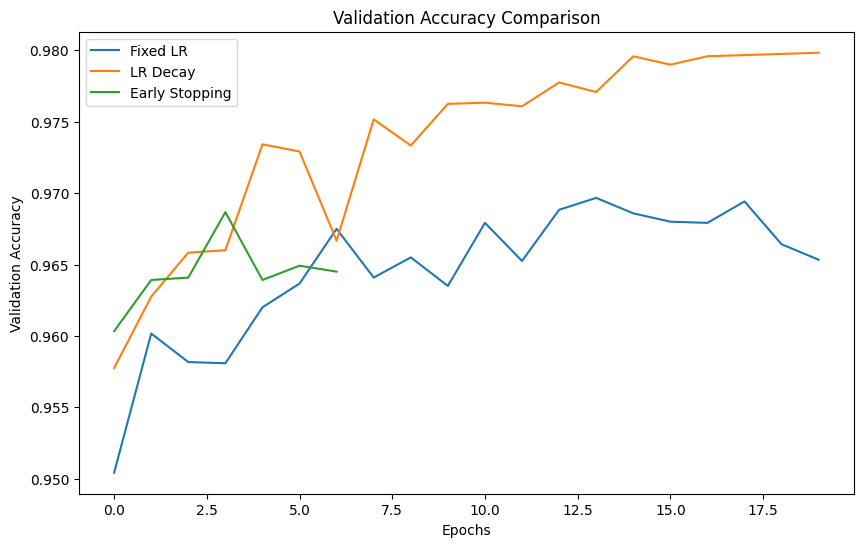

In [18]:
plt.figure(figsize=(10,6))
plt.plot(history_fixed.history['val_accuracy'], label='Fixed LR')
plt.plot(history_decay.history['val_accuracy'], label='LR Decay')
plt.plot(history_early.history['val_accuracy'], label='Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Validation Accuracy Comparison')
plt.show()


Loss Comparison

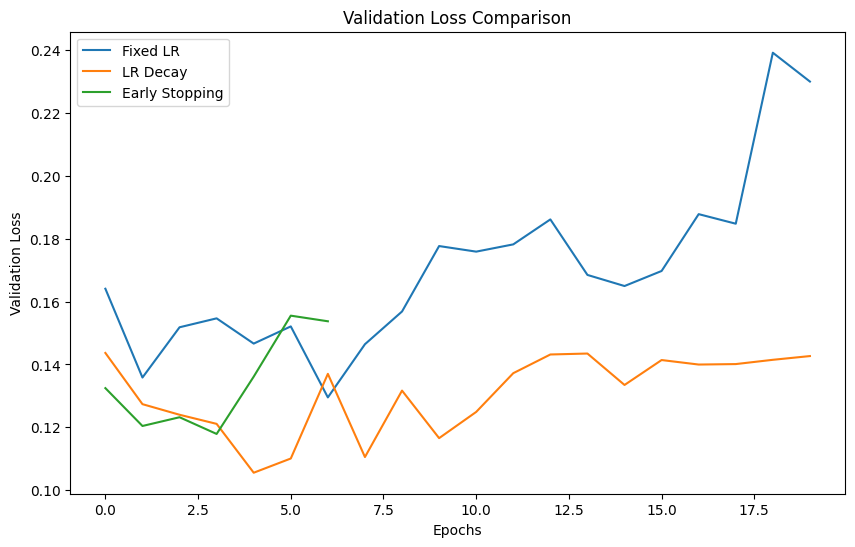

In [19]:
plt.figure(figsize=(10,6))
plt.plot(history_fixed.history['val_loss'], label='Fixed LR')
plt.plot(history_decay.history['val_loss'], label='LR Decay')
plt.plot(history_early.history['val_loss'], label='Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.title('Validation Loss Comparison')
plt.show()
